In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.utils import median_survival_times
from src.util import analyze_case_duplicates

In [2]:
clinical_data = pd.read_csv("data/clinical_cohort_2026-04-02/clinical.tsv", sep ="\t")

In [3]:
pd.set_option('display.max_rows', None)
print(clinical_data["diagnoses.primary_diagnosis"].value_counts())

diagnoses.primary_diagnosis
Clear cell adenocarcinoma, NOS                                     987
Not Reported                                                       720
Wilms tumor                                                        652
Papillary adenocarcinoma, NOS                                      622
Renal cell carcinoma, NOS                                          428
Renal cell carcinoma, chromophobe type                             276
Clear cell carcinoma                                               144
Nephroblastoma, NOS                                                126
Papillary renal cell carcinoma                                      98
Adenocarcinoma, NOS                                                 88
Urothelial carcinoma, NOS                                           66
Malignant rhabdoid tumor                                            61
Neuroblastoma, NOS                                                  46
Carcinoma, NOS                                   

In [4]:
clinical_data = clinical_data.loc[clinical_data["diagnoses.primary_diagnosis"].isin(["Clear cell carcinoma", "Clear cell adenocarcinoma, NOS"]),:]

In [5]:
cols = ["project.project_id","cases.case_id","cases.disease_type","demographic.days_to_death", "demographic.ethnicity", "demographic.gender", "demographic.race", "demographic.vital_status","diagnoses.ajcc_pathologic_m",
       "diagnoses.ajcc_pathologic_n","diagnoses.ajcc_pathologic_stage", "diagnoses.classification_of_tumor", "diagnoses.days_to_last_follow_up",
       "diagnoses.days_to_recurrence","diagnoses.tissue_or_organ_of_origin", "diagnoses.prior_treatment", "diagnoses.primary_diagnosis", "treatments.treatment_type"]

In [6]:
clinical_data = clinical_data.loc[:,cols]
clinical_data = clinical_data.loc[clinical_data["diagnoses.classification_of_tumor"] == "primary",:]


In [7]:
clinical_data.head()

,project.project_id,cases.case_id,cases.disease_type,demographic.days_to_death,demographic.ethnicity,demographic.gender,demographic.race,demographic.vital_status,diagnoses.ajcc_pathologic_m,diagnoses.ajcc_pathologic_n,diagnoses.ajcc_pathologic_stage,diagnoses.classification_of_tumor,diagnoses.days_to_last_follow_up,diagnoses.days_to_recurrence,diagnoses.tissue_or_organ_of_origin,diagnoses.prior_treatment,diagnoses.primary_diagnosis,treatments.treatment_type
5,TCGA-KIRC,0022478c-4dfd-4cbe-a05e-fb20310844e3,Adenomas and Adenocarcinomas,563,not hispanic or latino,male,white,Dead,M0,N0,Stage I,primary,563.0,'--,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS",'--
8,FM-AD,003a2aa8-ceb2-44cd-ba56-76f0f45368cc,Adenomas and Adenocarcinomas,'--,not reported,female,not reported,Not Reported,'--,'--,'--,primary,'--,'--,"Kidney, NOS",'--,Clear cell carcinoma,'--
9,FM-AD,003e3496-338a-4424-9c51-5a2357142202,Adenomas and Adenocarcinomas,'--,not reported,female,not reported,Not Reported,'--,'--,'--,primary,'--,'--,"Kidney, NOS",'--,Clear cell carcinoma,'--
14,FM-AD,008517f3-8a93-4f6a-b97d-82ac3fe67707,Adenomas and Adenocarcinomas,'--,not reported,male,not reported,Not Reported,'--,'--,'--,primary,'--,'--,"Kidney, NOS",'--,Clear cell carcinoma,'--
25,TCGA-KIRC,01277e9d-a35f-45d9-9e60-2e8cd79630a0,Adenomas and Adenocarcinomas,'--,not hispanic or latino,male,black or african american,Alive,MX,NX,Stage I,primary,2470.0,'--,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS","Pharmaceutical Therapy, NOS"


In [8]:
result = analyze_case_duplicates(clinical_data , case_id_col = "cases.case_id")

In [25]:
differing = [r for r in result if isinstance(r["status"], list)]

#not_treatment =[ l for l in differing if l["status"]!=["treatments.treatment_type"]]

In [26]:
differing[1:10]

[{'case_id': '037c691e-6320-451b-9276-78459f1b705c',
  'row_count': 4,
  'status': ['treatments.treatment_type']},
 {'case_id': '04beccb3-f513-4d60-b57f-a4382e4eeda3',
  'row_count': 2,
  'status': ['treatments.treatment_type']},
 {'case_id': '06197e26-3cb0-4bd0-a6e8-dd9af5047c6a',
  'row_count': 5,
  'status': ['treatments.treatment_type']},
 {'case_id': '08a8eec3-c97a-4493-a7de-b2a686b4df67',
  'row_count': 2,
  'status': ['treatments.treatment_type']},
 {'case_id': '08c1bb22-81f5-4a6d-98ce-f9c31d896eab',
  'row_count': 2,
  'status': ['treatments.treatment_type']},
 {'case_id': '0a6a375b-3b61-453f-a64a-db3d49352949',
  'row_count': 2,
  'status': ['treatments.treatment_type']},
 {'case_id': '11111b58-c7df-4291-ad8a-4baec9ff7d1f',
  'row_count': 3,
  'status': ['treatments.treatment_type']},
 {'case_id': '171044a9-9e8e-419b-af3a-4849d92c3b1e',
  'row_count': 2,
  'status': ['treatments.treatment_type']},
 {'case_id': '18325fdc-594b-4545-a77d-adb07a32ec73',
  'row_count': 2,
  'status

In [24]:
p

[]

In [15]:
clinical_data.shape
       


(865, 18)

In [110]:
clinical_data["demographic.days_to_death"].value_counts()

demographic.days_to_death
'--     712
2227     15
646      13
1625     12
336      11
679      10
1912     10
2105      9
344       8
1034      8
480       7
313       7
782       7
885       6
162       6
1610      6
330       6
768       6
3554      6
1173      6
431       5
866       5
552       5
224       5
1092      5
574       5
2764      5
878       5
1200      5
1432      5
722       5
1567      5
1724      4
478       4
587       4
211       4
709       4
445       4
561       3
683       3
600       3
946       3
927       3
845       3
1003      3
1121      3
137       3
727       3
992       3
952       3
475       3
1626      3
822       2
1714      2
2241      2
701       2
242       2
3615      2
1696      2
510       2
1091      2
139       2
204       2
1964      2
333       2
1170      2
1111      2
329       2
645       2
0         2
563       1
1657      1
1317      1
320       1
164       1
883       1
1191      1
735       1
106       1
454       1
578       1
30

In [112]:
clinical_data.reset_index(inplace=True)

In [128]:
duplicates = clinical_data["cases.case_id"].duplicated()

In [130]:
clinical_data.loc[duplicates, :][1:10]

,index,project.project_id,cases.case_id,cases.disease_type,demographic.days_to_death,demographic.ethnicity,demographic.gender,demographic.race,demographic.vital_status,diagnoses.ajcc_pathologic_m,...,diagnoses.ajcc_pathologic_stage,diagnoses.ajcc_pathologic_stage,diagnoses.classification_of_tumor,diagnoses.days_to_last_follow_up,diagnoses.days_to_recurrence,diagnoses.prior_treatment,diagnoses.tissue_or_organ_of_origin,diagnoses.prior_treatment,diagnoses.primary_diagnosis,treatments.treatment_type
16,57,TCGA-KIRC,037c691e-6320-451b-9276-78459f1b705c,Adenomas and Adenocarcinomas,344,not hispanic or latino,female,white,Dead,M1,...,Stage IV,Stage IV,primary,344.0,'--,No,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS","Radiation Therapy, NOS"
17,58,TCGA-KIRC,037c691e-6320-451b-9276-78459f1b705c,Adenomas and Adenocarcinomas,344,not hispanic or latino,female,white,Dead,M1,...,Stage IV,Stage IV,primary,344.0,'--,No,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS",Targeted Molecular Therapy
18,59,TCGA-KIRC,037c691e-6320-451b-9276-78459f1b705c,Adenomas and Adenocarcinomas,344,not hispanic or latino,female,white,Dead,M1,...,Stage IV,Stage IV,primary,344.0,'--,No,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS","Radiation Therapy, NOS"
36,99,TCGA-KIRC,04beccb3-f513-4d60-b57f-a4382e4eeda3,Adenomas and Adenocarcinomas,'--,not reported,female,black or african american,Alive,'--,...,Stage I,Stage I,primary,431.0,'--,No,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS","Pharmaceutical Therapy, NOS"
39,115,TCGA-KIRC,06197e26-3cb0-4bd0-a6e8-dd9af5047c6a,Adenomas and Adenocarcinomas,431,not hispanic or latino,female,white,Dead,M1,...,Stage IV,Stage IV,primary,431.0,'--,No,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS",Chemotherapy
40,116,TCGA-KIRC,06197e26-3cb0-4bd0-a6e8-dd9af5047c6a,Adenomas and Adenocarcinomas,431,not hispanic or latino,female,white,Dead,M1,...,Stage IV,Stage IV,primary,431.0,'--,No,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS",Chemotherapy
41,117,TCGA-KIRC,06197e26-3cb0-4bd0-a6e8-dd9af5047c6a,Adenomas and Adenocarcinomas,431,not hispanic or latino,female,white,Dead,M1,...,Stage IV,Stage IV,primary,431.0,'--,No,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS",Chemotherapy
42,118,TCGA-KIRC,06197e26-3cb0-4bd0-a6e8-dd9af5047c6a,Adenomas and Adenocarcinomas,431,not hispanic or latino,female,white,Dead,M1,...,Stage IV,Stage IV,primary,431.0,'--,No,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS",Chemotherapy
45,137,TCGA-KIRC,06d86d68-0fd5-4c6e-8783-ed732a3291e8,Adenomas and Adenocarcinomas,'--,hispanic or latino,male,white,Alive,M0,...,Stage III,Stage III,primary,2554.0,'--,No,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS",Targeted Molecular Therapy


In [118]:
clinical_data.head()

,index,project.project_id,cases.case_id,cases.disease_type,demographic.days_to_death,demographic.ethnicity,demographic.gender,demographic.race,demographic.vital_status,diagnoses.ajcc_pathologic_m,...,diagnoses.ajcc_pathologic_stage,diagnoses.ajcc_pathologic_stage,diagnoses.classification_of_tumor,diagnoses.days_to_last_follow_up,diagnoses.days_to_recurrence,diagnoses.prior_treatment,diagnoses.tissue_or_organ_of_origin,diagnoses.prior_treatment,diagnoses.primary_diagnosis,treatments.treatment_type
0,5,TCGA-KIRC,0022478c-4dfd-4cbe-a05e-fb20310844e3,Adenomas and Adenocarcinomas,563,not hispanic or latino,male,white,Dead,M0,...,Stage I,Stage I,primary,563.0,'--,No,"Kidney, NOS",No,"Clear cell adenocarcinoma, NOS",'--
1,8,FM-AD,003a2aa8-ceb2-44cd-ba56-76f0f45368cc,Adenomas and Adenocarcinomas,'--,not reported,female,not reported,Not Reported,'--,...,'--,'--,primary,'--,'--,'--,"Kidney, NOS",'--,Clear cell carcinoma,'--
2,9,FM-AD,003e3496-338a-4424-9c51-5a2357142202,Adenomas and Adenocarcinomas,'--,not reported,female,not reported,Not Reported,'--,...,'--,'--,primary,'--,'--,'--,"Kidney, NOS",'--,Clear cell carcinoma,'--
3,14,FM-AD,008517f3-8a93-4f6a-b97d-82ac3fe67707,Adenomas and Adenocarcinomas,'--,not reported,male,not reported,Not Reported,'--,...,'--,'--,primary,'--,'--,'--,"Kidney, NOS",'--,Clear cell carcinoma,'--
4,22,TCGA-KIRC,01277e9d-a35f-45d9-9e60-2e8cd79630a0,Adenomas and Adenocarcinomas,'--,not hispanic or latino,male,black or african american,Alive,MX,...,Stage I,Stage I,Synchronous primary,'--,'--,'--,"Kidney, NOS",'--,Clear cell carcinoma,"Radiation Therapy, NOS"


In [119]:
clinical_data["demographic.days_to_death"].isin(["'--"]).sum()

np.int64(712)

In [120]:
clinical_data[["demographic.days_to_death", "diagnoses.days_to_last_follow_up", "demographic.vital_status"]][1:5]

,demographic.days_to_death,diagnoses.days_to_last_follow_up,demographic.vital_status
1,'--,'--,Not Reported
2,'--,'--,Not Reported
3,'--,'--,Not Reported
4,'--,'--,Alive


In [121]:
rows = clinical_data["diagnoses.days_to_last_follow_up"]!="'--"

In [122]:
sur_df = clinical_data.loc[rows, ["diagnoses.days_to_last_follow_up", "demographic.vital_status", "demographic.gender"]]

(804, 3)

In [63]:
sur_df["Event"] = 0
sur_df.loc[sur_df["demographic.vital_status"] == "Dead", "Event"] = 1

In [64]:
sur_df = sur_df.rename(columns={"diagnoses.days_to_last_follow_up": "Days"})

sur_df['Years'] = sur_df['Days'].astype(float)/ 365.0

In [78]:
sur_df.shape

(804, 5)

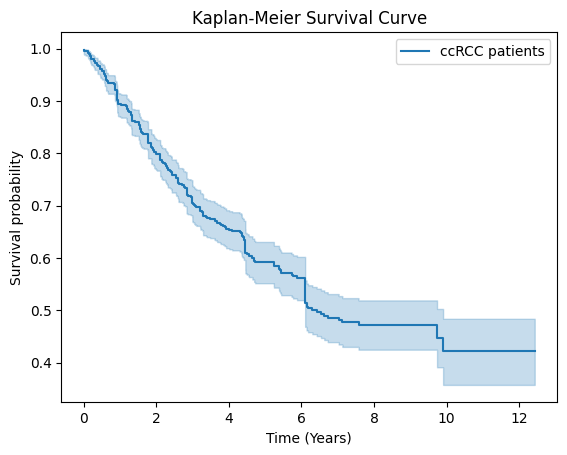

In [65]:
kmf = KaplanMeierFitter()
kmf.fit(durations = sur_df["Years"], event_observed = sur_df["Event"], label = "ccRCC patients")
ax = kmf.plot_survival_function()
ax.set_title("Kaplan-Meier Survival Curve")
ax.set_xlabel("Time (Years)")
ax.set_ylabel("Survival probability")
plt.show()


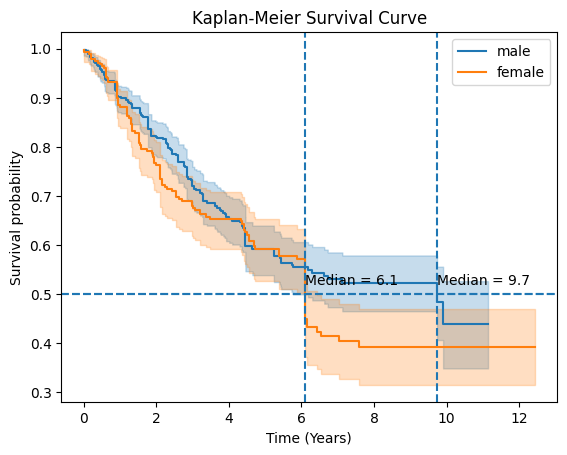

In [76]:
kmf = KaplanMeierFitter()
gp = ["male", 'female']

plt.figure()
for g in gp:
    sel_rw = sur_df["demographic.gender"] == g
    kmf.fit(durations = sur_df.loc[sel_rw,"Years"], event_observed = sur_df.loc[sel_rw,"Event"], label = g)
    median = kmf.median_survival_time_
    ax = kmf.plot_survival_function()
    ax.axhline(0.5, linestyle = "--")
    ax.axvline(median, linestyle = "--")
    ax.text(median, 0.52, f"Median = {median:.1f}")

ax.set_title("Kaplan-Meier Survival Curve")
ax.set_xlabel("Time (Years)")
ax.set_ylabel("Survival probability")
plt.show() 


